# Operator Validation First (No GMRES): Single-Source 32↔64

This notebook follows the advisor guidance exactly:
- Do **not** use GMRES until operator transfer is validated.
- Start from an easy regime: **single random source in uniform medium**.
- Use ω = 32 and 64 only.
- Default training data uses **no PML/windowing** (`npml = 0`).
- Add onion layers: training convergence, hyperparameter tuning, dataset-size scaling.


## 0) Imports and Reproducibility

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from itertools import product
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120


## 1) Run Configuration

We keep geometry fixed and lightweight so training/diagnostics are repeatable.
Default is `npml = 0` to remove windowing from the training set.

In [2]:
@dataclass
class RunCfg:
    seed: int = 42
    n_tot: int = 500
    npml: int = 104
    pml_eta: float = 70.0
    pml_power: float = 2.0
    stencil_order: int = 2
    omega_low: float = 32.0
    omega_high: float = 64.0
    source_margin: int = 16
    amp_min: float = 1.0
    amp_max: float = 1.0
    n_train: int = 240
    n_val: int = 60
    n_test: int = 60
    batch_size: int = 8
    epochs: int = 120
    lr: float = 1e-3
    weight_decay: float = 1e-6
    scheduler_patience: int = 10
    scheduler_factor: float = 0.5
    early_stop_patience: int = 20
    grad_clip: float = 1.0

cfg = RunCfg()
rng = np.random.default_rng(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", device)
print(cfg)


device: cpu
RunCfg(seed=42, n_tot=500, npml=104, pml_eta=70.0, pml_power=2.0, stencil_order=2, omega_low=32.0, omega_high=64.0, source_margin=16, amp_min=1.0, amp_max=1.0, n_train=240, n_val=60, n_test=60, batch_size=8, epochs=120, lr=0.001, weight_decay=1e-06, scheduler_patience=10, scheduler_factor=0.5, early_stop_patience=20, grad_clip=1.0)


/math/home/fkiewiet/Freq2Transfer/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 2) PDE Utilities (No GMRES)

Direct sparse solves only. This isolates operator quality from iterative solver effects.

In [3]:
def sigma_profile_1d(n_tot: int, n_pml: int, eta: float, pml_power: float) -> np.ndarray:
    sig = np.zeros(n_tot, dtype=float)
    if n_pml <= 0:
        return sig
    for i in range(n_tot):
        if i < n_pml:
            dist = (n_pml - i) / n_pml
        elif i >= n_tot - n_pml:
            dist = (i - (n_tot - n_pml) + 1) / n_pml
        else:
            dist = 0.0
        sig[i] = eta * (dist ** pml_power)
    return sig


def get_helmholtz_matrix(*, omega: float, n_tot: int, n_pml: int, eta: float, pml_power: float, stencil_order: int = 2):
    if stencil_order not in (2, 4):
        raise ValueError("stencil_order must be 2 or 4")
    h = 1.0 / (n_tot - 1)
    sig = sigma_profile_1d(n_tot, n_pml, eta, pml_power)
    s = 1.0 / (1.0 + 1j * sig / (omega / (2.0 * np.pi)))

    rows, cols, vals = [], [], []
    def add(r, c, v):
        rows.append(r)
        cols.append(c)
        vals.append(v)
    def lin(i, j):
        return i * n_tot + j

    d2, o21 = -2.0, 1.0
    d4, o41, o42 = -2.5, 4.0 / 3.0, -1.0 / 12.0
    k2 = float(omega) * float(omega)

    for i in range(n_tot):
        sy2 = s[i] * s[i]
        for j in range(n_tot):
            r = lin(i, j)
            if i == 0 or j == 0 or i == n_tot - 1 or j == n_tot - 1:
                add(r, r, 1.0 + 0.0j)
                continue
            sx2 = s[j] * s[j]
            use_2nd = (stencil_order == 2 or i < 2 or j < 2 or i > n_tot - 3 or j > n_tot - 3)
            if use_2nd:
                add(r, r, ((sx2 * d2 + sy2 * d2) / (h * h)) + k2)
                add(r, lin(i, j - 1), sx2 * o21 / (h * h))
                add(r, lin(i, j + 1), sx2 * o21 / (h * h))
                add(r, lin(i - 1, j), sy2 * o21 / (h * h))
                add(r, lin(i + 1, j), sy2 * o21 / (h * h))
            else:
                add(r, r, ((sx2 * d4 + sy2 * d4) / (h * h)) + k2)
                add(r, lin(i, j - 1), sx2 * o41 / (h * h)); add(r, lin(i, j + 1), sx2 * o41 / (h * h))
                add(r, lin(i, j - 2), sx2 * o42 / (h * h)); add(r, lin(i, j + 2), sx2 * o42 / (h * h))
                add(r, lin(i - 1, j), sy2 * o41 / (h * h)); add(r, lin(i + 1, j), sy2 * o41 / (h * h))
                add(r, lin(i - 2, j), sy2 * o42 / (h * h)); add(r, lin(i + 2, j), sy2 * o42 / (h * h))

    return sp.coo_matrix((vals, (rows, cols)), shape=(n_tot * n_tot, n_tot * n_tot)).tocsr()


def make_single_source_rhs(n_tot: int, n_pml: int, margin: int, amp_min: float, amp_max: float, rng_local: np.random.Generator):
    f = np.zeros((n_tot, n_tot), dtype=np.complex128)
    lo = n_pml + margin
    hi = n_tot - n_pml - margin
    if hi <= lo:
        raise ValueError("source margin too large")
    i = int(rng_local.integers(lo, hi))
    j = int(rng_local.integers(lo, hi))
    amp = float(rng_local.uniform(amp_min, amp_max))
    phase = float(rng_local.uniform(0.0, 2 * np.pi))
    f[i, j] = amp * np.exp(1j * phase)
    return f


def solve_field(A: sp.csr_matrix, f2d: np.ndarray):
    u = spla.spsolve(A, f2d.reshape(-1))
    return u.reshape(f2d.shape)


def to_2ch(arr: np.ndarray) -> np.ndarray:
    return np.stack([arr.real, arr.imag], axis=0).astype(np.float32)


def from_2ch(arr2: np.ndarray) -> np.ndarray:
    return arr2[0] + 1j * arr2[1]


## 3) Operator Sanity Check (Before Any Learning)

We verify direct solves and residuals at ω=32 and 64 on a single random source.

In [4]:
A32 = get_helmholtz_matrix(
    omega=cfg.omega_low,
    n_tot=cfg.n_tot,
    n_pml=cfg.npml,
    eta=cfg.pml_eta,
    pml_power=cfg.pml_power,
    stencil_order=cfg.stencil_order,
)
A64 = get_helmholtz_matrix(
    omega=cfg.omega_high,
    n_tot=cfg.n_tot,
    n_pml=cfg.npml,
    eta=cfg.pml_eta,
    pml_power=cfg.pml_power,
    stencil_order=cfg.stencil_order,
)

f0 = make_single_source_rhs(
    cfg.n_tot,
    cfg.npml,
    getattr(cfg, "source_margin", getattr(cfg, "margin", 8)),
    getattr(cfg, "amp_min", getattr(cfg, "source_amp_min", 1.0)),
    getattr(cfg, "amp_max", getattr(cfg, "source_amp_max", getattr(cfg, "amp_min", 1.0))),
    rng,
)
u32_0 = solve_field(A32, f0)
u64_0 = solve_field(A64, f0)

r32 = f0.reshape(-1) - A32 @ u32_0.reshape(-1)
r64 = f0.reshape(-1) - A64 @ u64_0.reshape(-1)
print("npml:", cfg.npml)
print("||r32||2/||f||2 =", np.linalg.norm(r32) / max(np.linalg.norm(f0), 1e-30))
print("||r64||2/||f||2 =", np.linalg.norm(r64) / max(np.linalg.norm(f0), 1e-30))


npml: 104
||r32||2/||f||2 = 2.420640689484591e-14
||r64||2/||f||2 = 7.95191377483663e-14


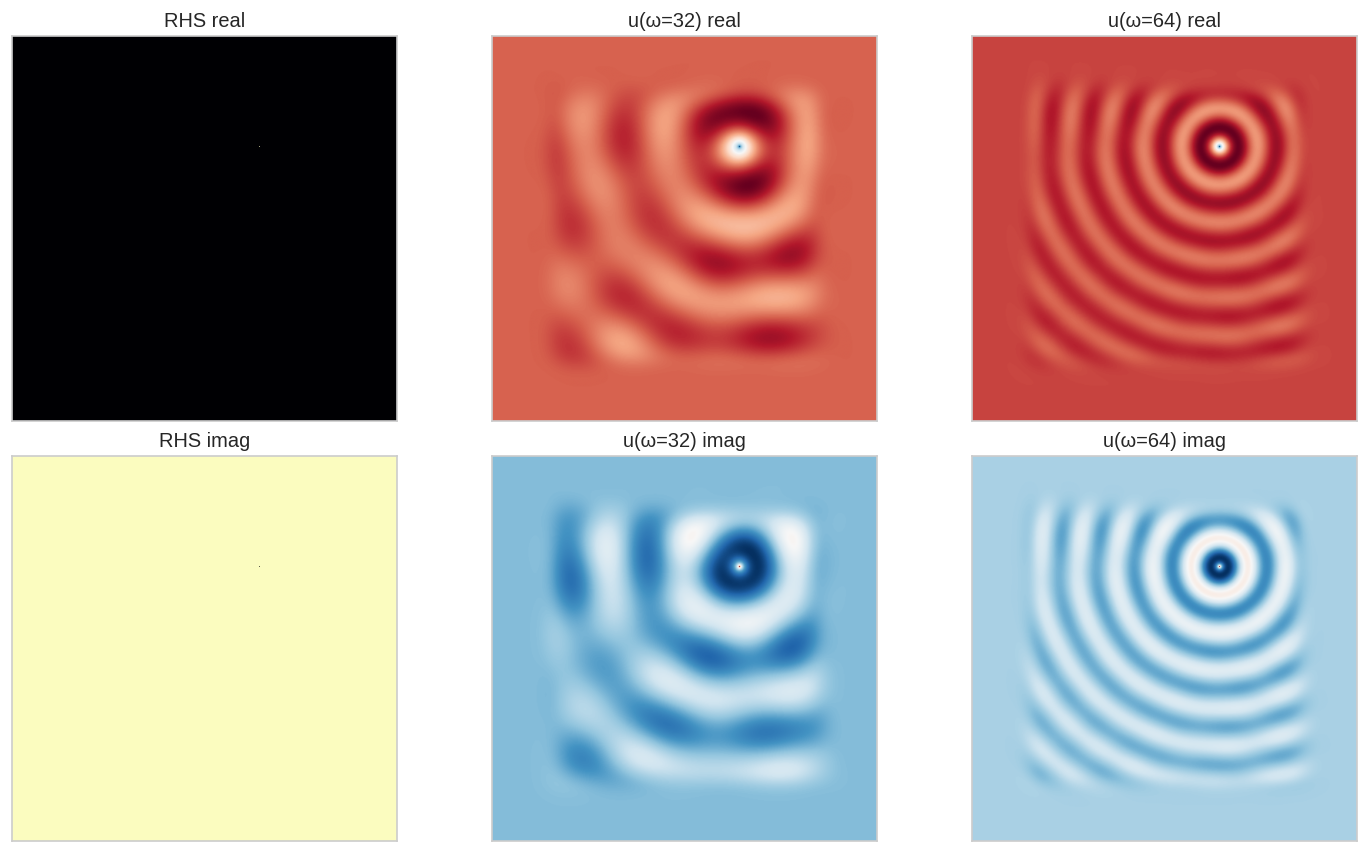

In [5]:
fig, axs = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
axs[0, 0].imshow(f0.real, cmap="magma"); axs[0, 0].set_title("RHS real")
axs[0, 1].imshow(u32_0.real, cmap="RdBu_r"); axs[0, 1].set_title("u(\u03c9=32) real")
axs[0, 2].imshow(u64_0.real, cmap="RdBu_r"); axs[0, 2].set_title("u(\u03c9=64) real")
axs[1, 0].imshow(f0.imag, cmap="magma"); axs[1, 0].set_title("RHS imag")
axs[1, 1].imshow(u32_0.imag, cmap="RdBu_r"); axs[1, 1].set_title("u(\u03c9=32) imag")
axs[1, 2].imshow(u64_0.imag, cmap="RdBu_r"); axs[1, 2].set_title("u(\u03c9=64) imag")
for ax in axs.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()


## 4) Dataset Builder: Single Source, Uniform Medium

Input and target use the **same RHS location/phase**, only operator changes by frequency.
- `up`: 32 → 64
- `down`: 64 → 32


In [6]:
def build_transfer_dataset(n_samples: int, seed: int, cfg_local: RunCfg):
    rng_local = np.random.default_rng(seed)
    X_up, Y_up = [], []
    X_dn, Y_dn = [], []
    for _ in range(n_samples):
        f = make_single_source_rhs(
            cfg_local.n_tot,
            cfg_local.npml,
            getattr(cfg_local, "source_margin", getattr(cfg_local, "margin", 8)),
            getattr(cfg_local, "amp_min", getattr(cfg_local, "source_amp_min", 1.0)),
            getattr(cfg_local, "amp_max", getattr(cfg_local, "source_amp_max", getattr(cfg_local, "amp_min", 1.0))),
            rng_local,
        )
        u32 = solve_field(A32, f)
        u64 = solve_field(A64, f)
        X_up.append(to_2ch(u32)); Y_up.append(to_2ch(u64))
        X_dn.append(to_2ch(u64)); Y_dn.append(to_2ch(u32))
    out = {
        "X_up": np.asarray(X_up, dtype=np.float32),
        "Y_up": np.asarray(Y_up, dtype=np.float32),
        "X_down": np.asarray(X_dn, dtype=np.float32),
        "Y_down": np.asarray(Y_dn, dtype=np.float32),
    }
    return out


train = build_transfer_dataset(cfg.n_train, cfg.seed + 1, cfg)
val = build_transfer_dataset(cfg.n_val, cfg.seed + 2, cfg)
test = build_transfer_dataset(cfg.n_test, cfg.seed + 3, cfg)

print("train up:", train["X_up"].shape, "->", train["Y_up"].shape)
print("train down:", train["X_down"].shape, "->", train["Y_down"].shape)


train up: (240, 2, 500, 500) -> (240, 2, 500, 500)
train down: (240, 2, 500, 500) -> (240, 2, 500, 500)


## 5) Scaling Definitions (Clarity)

We use three separate notions of scaling:
1. **Data normalization scaling**: channel-wise input/target scaling for stable training.
2. **Residual scaling**: report `||r||/||f||` where `r = f - A u_pred`.
3. **Update scaling**: report `||\u0394u||/||u_ref||` with `\u0394u = u_pred - u_init`.

Here `u_init` is identity transfer input (e.g., `u32` for 32→64).
No GMRES is used here.

In [ ]:
# Section 5 cell (replace existing scaling cell)
def channel_scale_fit(X: np.ndarray, eps: float = 1e-8):
    s = X.std(axis=(0, 2, 3)).astype(np.float32)
    s = np.maximum(s, eps)
    return s


def channel_scale_apply(X: np.ndarray, s: np.ndarray):
    return X / s[None, :, None, None]


def channel_scale_undo(X: np.ndarray, s: np.ndarray):
    return X * s[None, :, None, None]


def window_nonpml(X: np.ndarray, npml: int):
    if npml <= 0:
        return X
    return X[:, :, npml:-npml, npml:-npml]


sx_up = channel_scale_fit(train["X_up"])
sy_up = channel_scale_fit(train["Y_up"])
sx_dn = channel_scale_fit(train["X_down"])
sy_dn = channel_scale_fit(train["Y_down"])
print("up sx/sy:", sx_up, sy_up)
print("down sx/sy:", sx_dn, sy_dn)


up sx/sy: [1.6456141e-07 1.6416364e-07] [1.0533176e-07 1.0535445e-07]
down sx/sy: [1.0533176e-07 1.0535445e-07] [1.6456141e-07 1.6416364e-07]


## 6) Model and Training

In [8]:
class PlainCNN(nn.Module):
    def __init__(self, width: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, width, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(width, width, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(width, width, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(width, 2, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x)


def train_one_direction(Xtr, Ytr, Xva, Yva, *, width: int, lr: float, weight_decay: float, cfg_local: RunCfg):
    model = PlainCNN(width=width).to(device)
    ds = TensorDataset(torch.tensor(Xtr), torch.tensor(Ytr))
    dl = DataLoader(ds, batch_size=cfg_local.batch_size, shuffle=True, drop_last=False)

    xv = torch.tensor(Xva, dtype=torch.float32, device=device)
    yv = torch.tensor(Yva, dtype=torch.float32, device=device)

    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=cfg_local.scheduler_factor, patience=cfg_local.scheduler_patience
    )

    best = {"epoch": -1, "val": float("inf"), "state": None}
    history = []
    no_improve = 0

    for ep in range(1, cfg_local.epochs + 1):
        model.train()
        tr_losses = []
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = torch.mean((pred - yb) ** 2)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg_local.grad_clip)
            opt.step()
            tr_losses.append(float(loss.item()))

        model.eval()
        with torch.no_grad():
            pv = model(xv)
            val = float(torch.mean((pv - yv) ** 2).item())

        sched.step(val)
        tr = float(np.mean(tr_losses))
        lr_now = float(opt.param_groups[0]["lr"])
        history.append({"epoch": ep, "train_mse": tr, "val_mse": val, "lr": lr_now})

        if val < best["val"]:
            best["val"] = val
            best["epoch"] = ep
            best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= cfg_local.early_stop_patience:
            break

    model.load_state_dict(best["state"])
    return model, history, best


def predict_np(model: nn.Module, X: np.ndarray, batch_size: int):
    model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32, device=device)
            yb = model(xb).detach().cpu().numpy()
            outs.append(yb)
    return np.concatenate(outs, axis=0)


## 7) Metrics (Absolute + Relative + Physics Diagnostics)

In [ ]:
def metrics_2ch(pred: np.ndarray, true: np.ndarray):
    e = pred - true
    out = {
        "mse_re": float(np.mean((e[:, 0]) ** 2)),
        "mse_im": float(np.mean((e[:, 1]) ** 2)),
        "rel_l2_re": float(np.linalg.norm(e[:, 0].ravel()) / max(np.linalg.norm(true[:, 0].ravel()), 1e-30)),
        "rel_l2_im": float(np.linalg.norm(e[:, 1].ravel()) / max(np.linalg.norm(true[:, 1].ravel()), 1e-30)),
    }
    return out


def residual_ratio(A: sp.csr_matrix, u2: np.ndarray, f2: np.ndarray):
    u = from_2ch(u2)
    f = from_2ch(f2)
    r = f.reshape(-1) - A @ u.reshape(-1)
    return float(np.linalg.norm(r) / max(np.linalg.norm(f), 1e-30))


def update_ratio(u_pred2: np.ndarray, u_init2: np.ndarray, u_ref2: np.ndarray):
    du = from_2ch(u_pred2) - from_2ch(u_init2)
    u_ref = from_2ch(u_ref2)
    return float(np.linalg.norm(du) / max(np.linalg.norm(u_ref), 1e-30))


## 8) Onion Layer 1: Convergence on Easy Problem

Train one model per direction and compare against identity transfer.

In [10]:
# Section 8 cell (replace run_direction cell)
def run_direction(direction: str, cfg_local: RunCfg, width: int = 32, lr: float = 1e-3, wd: float = 1e-6):
    if direction == "up":
        Xtr, Ytr = train["X_up"], train["Y_up"]
        Xva, Yva = val["X_up"], val["Y_up"]
        Xte, Yte = test["X_up"], test["Y_up"]
        A_out = A64
        label = "ω=32 → 64"
    else:
        Xtr, Ytr = train["X_down"], train["Y_down"]
        Xva, Yva = val["X_down"], val["Y_down"]
        Xte, Yte = test["X_down"], test["Y_down"]
        A_out = A32
        label = "ω=64 → 32"

    # Window training/validation to physical domain (exclude PML).
    Xtr = window_nonpml(Xtr, cfg_local.npml)
    Ytr = window_nonpml(Ytr, cfg_local.npml)
    Xva = window_nonpml(Xva, cfg_local.npml)
    Yva = window_nonpml(Yva, cfg_local.npml)

    sx = channel_scale_fit(Xtr)
    sy = channel_scale_fit(Ytr)
    Xtr_n = channel_scale_apply(Xtr, sx)
    Ytr_n = channel_scale_apply(Ytr, sy)
    Xva_n = channel_scale_apply(Xva, sx)
    Yva_n = channel_scale_apply(Yva, sy)
    Xte_n = channel_scale_apply(Xte, sx)

    model, hist, best = train_one_direction(Xtr_n, Ytr_n, Xva_n, Yva_n, width=width, lr=lr, weight_decay=wd, cfg_local=cfg_local)
    pred_n = predict_np(model, Xte_n, batch_size=cfg_local.batch_size)
    pred = channel_scale_undo(pred_n, sy)

    id_pred = Xte.copy()
    m_id = metrics_2ch(id_pred, Yte)
    m_m = metrics_2ch(pred, Yte)

    rid = np.mean([residual_ratio(A_out, id_pred[k], Yte[k]) for k in range(len(Yte))])
    rmd = np.mean([residual_ratio(A_out, pred[k], Yte[k]) for k in range(len(Yte))])
    upd = np.mean([update_ratio(pred[k], id_pred[k], Yte[k]) for k in range(len(Yte))])

    row = {
        "transfer": label,
        "direction": direction,
        "best_epoch": int(best["epoch"]),
        "id_mse_re": m_id["mse_re"],
        "id_mse_im": m_id["mse_im"],
        "id_rel_l2_re": m_id["rel_l2_re"],
        "id_rel_l2_im": m_id["rel_l2_im"],
        "model_mse_re": m_m["mse_re"],
        "model_mse_im": m_m["mse_im"],
        "model_rel_l2_re": m_m["rel_l2_re"],
        "model_rel_l2_im": m_m["rel_l2_im"],
        "id_residual_ratio": float(rid),
        "model_residual_ratio": float(rmd),
        "update_ratio": float(upd),
    }
    for k in ["mse_re", "mse_im", "rel_l2_re", "rel_l2_im"]:
        row[f"{k}_improve_pct"] = 100.0 * (row[f"id_{k}"] - row[f"model_{k}"]) / max(row[f"id_{k}"], 1e-30)
    return row, hist, model, pred, Yte, id_pred


row_up, hist_up, model_up, pred_up, y_up, id_up = run_direction("up", cfg)
row_dn, hist_dn, model_dn, pred_dn, y_dn, id_dn = run_direction("down", cfg)
results_layer1 = pd.DataFrame([row_up, row_dn])
display(results_layer1)


,transfer,direction,best_epoch,id_mse_re,id_mse_im,id_rel_l2_re,id_rel_l2_im,model_mse_re,model_mse_im,model_rel_l2_re,model_rel_l2_im,id_residual_ratio,model_residual_ratio,update_ratio,mse_re_improve_pct,mse_im_improve_pct,rel_l2_re_improve_pct,rel_l2_im_improve_pct
0,ω=32 → 64,up,120,3.839655e-14,3.888478e-14,1.858516,1.870465,9.416888e-15,9.374916e-15,0.920401,0.918430,14134.330540,5299.537065,1.631114,75.474648,75.890526,50.476564,50.898325
1,ω=64 → 32,down,115,3.839655e-14,3.888478e-14,1.201789,1.199772,1.283495e-14,3.010060e-14,0.694453,1.055118,8980.765625,7835.577511,1.193926,66.572638,22.590267,42.215023,12.056737


## 9) Onion Layer 2: Hyperparameter Sweep

Small targeted sweep on the easy setup. We rank by mean validation MSE over both directions.

In [11]:
# Section 9 function cell (replace quick_val_score definition)
def quick_val_score(direction: str, width: int, lr: float, wd: float, cfg_local: RunCfg):
    if direction == "up":
        Xtr, Ytr, Xva, Yva = train["X_up"], train["Y_up"], val["X_up"], val["Y_up"]
    else:
        Xtr, Ytr, Xva, Yva = train["X_down"], train["Y_down"], val["X_down"], val["Y_down"]

    Xtr = window_nonpml(Xtr, cfg_local.npml)
    Ytr = window_nonpml(Ytr, cfg_local.npml)
    Xva = window_nonpml(Xva, cfg_local.npml)
    Yva = window_nonpml(Yva, cfg_local.npml)

    sx = channel_scale_fit(Xtr)
    sy = channel_scale_fit(Ytr)
    Xtr_n = channel_scale_apply(Xtr, sx)
    Ytr_n = channel_scale_apply(Ytr, sy)
    Xva_n = channel_scale_apply(Xva, sx)
    Yva_n = channel_scale_apply(Yva, sy)

    model, _, best = train_one_direction(Xtr_n, Ytr_n, Xva_n, Yva_n, width=width, lr=lr, weight_decay=wd, cfg_local=cfg_local)
    return float(best["val"])


## 10) Onion Layer 3: Dataset Size Sweep

Test whether training set is large enough, using best hyperparameters.

In [13]:
# Section 10 cell (replace run_with_train_size cell)
def run_with_train_size(n_train: int, cfg_base: RunCfg, width: int, lr: float, wd: float):
    cfg_local = RunCfg(**{**cfg_base.__dict__, "n_train": int(n_train)})
    tr = build_transfer_dataset(cfg_local.n_train, cfg_local.seed + 11, cfg_local)
    va = build_transfer_dataset(cfg_local.n_val, cfg_local.seed + 12, cfg_local)
    te = build_transfer_dataset(cfg_local.n_test, cfg_local.seed + 13, cfg_local)

    def one(direction: str):
        if direction == "up":
            Xtr, Ytr = tr["X_up"], tr["Y_up"]
            Xva, Yva = va["X_up"], va["Y_up"]
            Xte, Yte = te["X_up"], te["Y_up"]
        else:
            Xtr, Ytr = tr["X_down"], tr["Y_down"]
            Xva, Yva = va["X_down"], va["Y_down"]
            Xte, Yte = te["X_down"], te["Y_down"]

        Xtr = window_nonpml(Xtr, cfg_local.npml)
        Ytr = window_nonpml(Ytr, cfg_local.npml)
        Xva = window_nonpml(Xva, cfg_local.npml)
        Yva = window_nonpml(Yva, cfg_local.npml)

        sx = channel_scale_fit(Xtr)
        sy = channel_scale_fit(Ytr)
        Xtr_n = channel_scale_apply(Xtr, sx)
        Ytr_n = channel_scale_apply(Ytr, sy)
        Xva_n = channel_scale_apply(Xva, sx)
        Yva_n = channel_scale_apply(Yva, sy)
        Xte_n = channel_scale_apply(Xte, sx)

        model, _, _ = train_one_direction(Xtr_n, Ytr_n, Xva_n, Yva_n, width=width, lr=lr, weight_decay=wd, cfg_local=cfg_local)
        pred = channel_scale_undo(predict_np(model, Xte_n, cfg_local.batch_size), sy)
        m = metrics_2ch(pred, Yte)
        return 0.5 * (m["rel_l2_re"] + m["rel_l2_im"])

    rel_up = one("up")
    rel_dn = one("down")
    return {
        "n_train": n_train,
        "rel_l2_mean": 0.5 * (rel_up + rel_dn),
        "rel_l2_up": rel_up,
        "rel_l2_down": rel_dn,
    }


sizes = [64, 128, 192, 256]
size_rows = []
for n_train in sizes:
    size_rows.append(run_with_train_size(
        n_train=n_train,
        cfg_base=cfg,
        width=int(best_hp["width"]),
        lr=float(best_hp["lr"]),
        wd=float(best_hp["weight_decay"]),
    ))

size_df = pd.DataFrame(size_rows)
display(size_df)

plt.figure(figsize=(6, 4))
plt.plot(size_df["n_train"], size_df["rel_l2_mean"], marker="o")
plt.xlabel("n_train")
plt.ylabel("mean rel_l2 (up/down)")
plt.title("Dataset-size sweep (single-source, no GMRES)")
plt.show()


NameError: name 'best_hp' is not defined

## 11) Optional Check: Does Removing PML Help?

Quick A/B comparison with all else fixed (`npml = 0` vs `npml = 16`).
Keep this light; only for directionality.

In [ ]:
def quick_compare_npml(npml_values=(0, 16), n_train_small=96):
    rows = []
    for npml in npml_values:
        cfg_cmp = RunCfg(**{**cfg.__dict__, "npml": int(npml), "n_train": int(n_train_small), "n_val": 24, "n_test": 24, "epochs": 60})
        global A32, A64
        A32 = get_helmholtz_matrix(omega=cfg_cmp.omega_low, n_tot=cfg_cmp.n_tot, n_pml=cfg_cmp.npml, eta=cfg_cmp.pml_eta, pml_power=cfg_cmp.pml_power, stencil_order=cfg_cmp.stencil_order)
        A64 = get_helmholtz_matrix(omega=cfg_cmp.omega_high, n_tot=cfg_cmp.n_tot, n_pml=cfg_cmp.npml, eta=cfg_cmp.pml_eta, pml_power=cfg_cmp.pml_power, stencil_order=cfg_cmp.stencil_order)
        global train, val, test
        train = build_transfer_dataset(cfg_cmp.n_train, cfg_cmp.seed + 21, cfg_cmp)
        val = build_transfer_dataset(cfg_cmp.n_val, cfg_cmp.seed + 22, cfg_cmp)
        test = build_transfer_dataset(cfg_cmp.n_test, cfg_cmp.seed + 23, cfg_cmp)
        row_u, *_ = run_direction("up", cfg_cmp, width=int(best_hp["width"]), lr=float(best_hp["lr"]), wd=float(best_hp["weight_decay"]))
        row_d, *_ = run_direction("down", cfg_cmp, width=int(best_hp["width"]), lr=float(best_hp["lr"]), wd=float(best_hp["weight_decay"]))
        rows.append({
            "npml": npml,
            "up_rel_l2_mean": 0.5 * (row_u["model_rel_l2_re"] + row_u["model_rel_l2_im"]),
            "down_rel_l2_mean": 0.5 * (row_d["model_rel_l2_re"] + row_d["model_rel_l2_im"]),
            "mean_rel_l2": 0.25 * (
                row_u["model_rel_l2_re"] + row_u["model_rel_l2_im"] + row_d["model_rel_l2_re"] + row_d["model_rel_l2_im"]
            ),
        })
    return pd.DataFrame(rows)


cmp_df = quick_compare_npml()
display(cmp_df)


## 12) What To Lock Before GMRES

Proceed only if all are true:
1. Stable training convergence in both directions at 32↔64.
2. Model beats identity on MSE and relative-L2 in both directions.
3. Residual ratio improves vs identity, and update ratio is not pathological.
4. Hyperparameters and dataset size are in a stable region (not fragile).
5. Chosen PML/no-PML data strategy is justified by the quick A/B check.


In [ ]:
# Save trained artifacts so evaluation can continue later
from pathlib import Path
import json
import torch
import pandas as pd

save_dir = Path("experiments/checkpoints/session_32_64")
save_dir.mkdir(parents=True, exist_ok=True)

# 1) Save models (works for either `models` dict or single `model_up/model_dn`)
if "models" in globals():
    for key, m in models.items():
        name = f"{key[0]}_{key[1]}".replace(" ", "")
        torch.save(m.state_dict(), save_dir / f"{name}.pth")
else:
    if "model_up" in globals():
        torch.save(model_up.state_dict(), save_dir / "omega32_to_64_up.pth")
    if "model_dn" in globals():
        torch.save(model_dn.state_dict(), save_dir / "omega64_to_32_down.pth")

# 2) Save tabular outputs if present
if "results_df" in globals():
    results_df.to_csv(save_dir / "results.csv", index=False)
if "hist_df" in globals():
    hist_df.to_csv(save_dir / "history.csv", index=False)

# 3) Save run config/metadata
meta = {}
if "cfg" in globals():
    meta["cfg"] = cfg.__dict__
if "best_hp" in globals():
    meta["best_hp"] = {k: (float(v) if isinstance(v, (int, float)) else v) for k, v in best_hp.items()}

with open(save_dir / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved checkpoint bundle to:", save_dir)
